In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("data/Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [16]:
X=df.drop("sales",axis=1)
X.head()
y=df["sales"]

In [17]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)

polynomial_converter.fit(X)
poly_features=polynomial_converter.transform(X)



,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [19]:
poly_features

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]],
      shape=(200, 9))

In [20]:
np.random.seed(101)
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test=train_test_split(poly_features,y ,test_size=0.2)

from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
predicted_features=model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error

MAE=mean_absolute_error(predicted_features,y_test)

In [24]:
MSE =mean_squared_error(predicted_features,y_test)

In [25]:
RMSE=root_mean_squared_error(predicted_features,y_test)

In [26]:
MAE

0.44310658314806

In [27]:
MSE

0.3374972037419545

In [28]:
RMSE

0.580945095290385

In [45]:
train_rmse_errors=[]
test_rmse_errors=[]

for i in range(1,10):
    poly_converter =PolynomialFeatures(degree=i,include_bias=False)
    poly_converter.fit(X)
    poly_features=poly_converter.transform(X)
    X_train,X_test,y_train,y_test=train_test_split(poly_features,y,test_size=0.2)
    model=LinearRegression()
    model.fit(X_train,y_train)
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_rmse=root_mean_squared_error(train_pred,y_train)
    test_rmse=root_mean_squared_error(test_pred,y_test)

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

In [46]:
train_rmse_errors

[1.6375994845061383,
 0.5037511004325866,
 0.35978980361452056,
 0.3032527412426855,
 0.26035917494027194,
 0.2745729611192164,
 0.2668123489830731,
 0.41122514748821637,
 0.6583238140944138]

In [47]:
test_rmse_errors

[1.8053748740153048,
 0.9598399590003569,
 0.8416301624667626,
 0.9425723355645206,
 0.46713050111316423,
 0.6669155831149508,
 2.7367876675106575,
 4058.0563374596127,
 496.65426542874866]

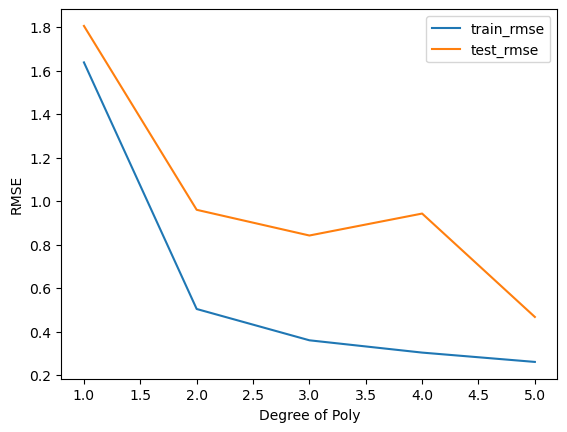

In [60]:
fig ,ax=plt.subplots()

ax.plot(range(1,6),train_rmse_errors[:5],label="train_rmse")
ax.plot(range(1,6),test_rmse_errors[:5],label="test_rmse")
ax.set(ylabel="RMSE",xlabel="Degree of Poly")
ax.legend();

In [61]:
final_poly_converter = PolynomialFeatures(degree=3,include_bias=False)

In [62]:
final_poly_converter.fit(X)

,degree,3
,interaction_only,False
,include_bias,False
,order,'C'


In [65]:
final_poly_features=final_poly_converter.transform(X)
final_poly_features

array([[2.30100000e+02, 3.78000000e+01, 6.92000000e+01, ...,
        9.88757280e+04, 1.81010592e+05, 3.31373888e+05],
       [4.45000000e+01, 3.93000000e+01, 4.51000000e+01, ...,
        6.96564990e+04, 7.99365930e+04, 9.17338510e+04],
       [1.72000000e+01, 4.59000000e+01, 6.93000000e+01, ...,
        1.46001933e+05, 2.20434291e+05, 3.32812557e+05],
       ...,
       [1.77000000e+02, 9.30000000e+00, 6.40000000e+00, ...,
        5.53536000e+02, 3.80928000e+02, 2.62144000e+02],
       [2.83600000e+02, 4.20000000e+01, 6.62000000e+01, ...,
        1.16776800e+05, 1.84062480e+05, 2.90117528e+05],
       [2.32100000e+02, 8.60000000e+00, 8.70000000e+00, ...,
        6.43452000e+02, 6.50934000e+02, 6.58503000e+02]], shape=(200, 19))

In [70]:
model=LinearRegression()
trained_model=model.fit(final_poly_features,y)
trained_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
from joblib import dump,load

In [71]:
dump(trained_model,"final_poly_model.joblib")

['final_poly_model.joblib']

In [72]:
dump(final_poly_converter,"fina_poly_converter.joblib")

['fina_poly_converter.joblib']

In [73]:
loaded_conveter=load('fina_poly_converter.joblib')

In [74]:
loaded_model=load('final_poly_model.joblib')

In [75]:
campaign =[[149,22,12]]

In [80]:
campaign_transformed_features=loaded_conveter.fit_transform(campaign)

In [81]:
loaded_model.predict(campaign_transformed_features)

array([14.64501014])